# Problem 1: Analyzing vehicle and pedestrian stops from law enforcement departments across Rhode Island

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load the data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/police_ri.csv'
ri = pd.read_csv(url, parse_dates={'stop_datetime': ['stop_date','stop_time']})

The 'ri' DataFrame contains data on vehicle and pedestrian stops from law enforcement departments across the state of Rhode Island.
This dataset has been obtained from the [Standford Open Police Project](https://openpolicing.stanford.edu/).

In [3]:
ri.head()

,stop_datetime,county_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,2005-01-02 01:55:00,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,2005-01-18 08:15:00,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,2005-01-23 23:15:00,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2005-02-20 17:15:00,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,2005-03-14 10:00:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


**Part 1:** Remove the column that only contains missing values

In [4]:
ri.search_type.value_counts()

Incident to Arrest                                          1219
Probable Cause                                               891
Inventory                                                    220
Reasonable Suspicion                                         197
Protective Frisk                                             161
Incident to Arrest,Inventory                                 129
Incident to Arrest,Probable Cause                            106
Probable Cause,Reasonable Suspicion                           75
Incident to Arrest,Inventory,Probable Cause                   34
Incident to Arrest,Protective Frisk                           33
Probable Cause,Protective Frisk                               33
Inventory,Probable Cause                                      22
Incident to Arrest,Reasonable Suspicion                       13
Incident to Arrest,Inventory,Protective Frisk                 11
Inventory,Protective Frisk                                    11
Protective Frisk,Reasonab

In [5]:
ri.county_name.value_counts()

Series([], Name: county_name, dtype: int64)

In [6]:
ri = ri.drop('county_name', axis=1)

**Part 2:** Do men or women speed more often?

In [7]:
ri.groupby('driver_gender').stop_datetime.count()

driver_gender
F    23511
M    62895
Name: stop_datetime, dtype: int64

Men.

**Part 3:** Does gender affect who gets searched during a stop?

In [8]:
ri.groupby('driver_gender').search_conducted.mean()

driver_gender
F    0.020033
M    0.043326
Name: search_conducted, dtype: float64

**Part 4:** Why is search_type missing so often?

When a search is not conducted, no search type is included:

In [9]:
ri.search_type[ri.search_conducted==False].value_counts()

Series([], Name: search_type, dtype: int64)

**Part 5:** During a search, how often is the driver frisked?

In [10]:
100*ri.search_type[ri.search_conducted==True].str.contains('Frisk').mean()

8.573216520650814

About 8.5% of stops involve a frisk.

**Part 6:**  Which year had the least number of stops?

In [11]:
ri['stop_year'] = ri.stop_datetime.dt.year

In [12]:
ri.groupby('stop_year').stop_datetime.count().sort_values(ascending=True)

stop_year
2005     2558
2010     7561
2009     7908
2013     7924
2011     8126
2015     8599
2008     8752
2014     9228
2007     9476
2006    10639
2012    10970
Name: stop_datetime, dtype: int64

2005

**Part 7:** How does drug activity change by time of day?

In [13]:
ri['Time'] = ri.stop_datetime.dt.time

<AxesSubplot:xlabel='Time'>

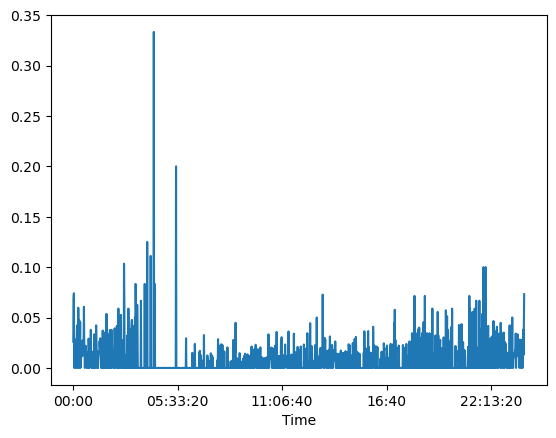

In [14]:
ri.groupby('Time').drugs_related_stop.mean().plot()

Drug related stops increase at night and decrease in the mid-morning

**Part 8:** Do most stops occur at night?

<AxesSubplot:xlabel='Time'>

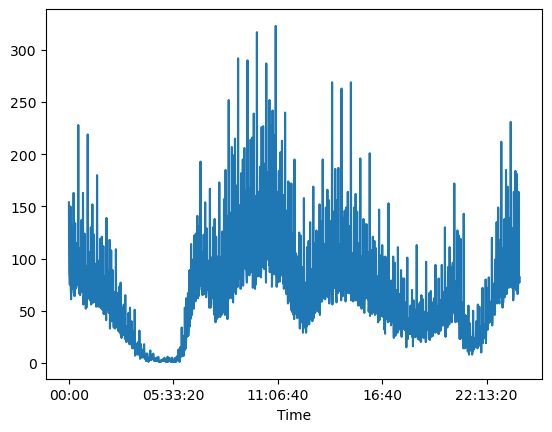

In [15]:
ri.groupby('Time').stop_datetime.count().plot()

No, most stops occur in the day

**Part 9:** Find the bad data in the stop_duration column and fix it

In [16]:
ri.stop_duration.value_counts()

0-15 Min     69543
16-30 Min    13635
30+ Min       3228
2                1
1                1
Name: stop_duration, dtype: int64

In [17]:
ri[(ri.stop_duration == '1')|(ri.stop_duration == '2')]

,stop_datetime,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop,stop_year,Time
55873,2012-01-23 11:17:00,M,1960.0,52.0,Black,Other Traffic Violation,Moving violation,False,NaN,Arrest Passenger,True,2,False,2012,11:17:00
76624,2014-04-13 08:34:00,F,1965.0,49.0,White,Speeding,Speeding,False,NaN,Citation,False,1,False,2014,08:34:00


These two rows have 'bad' values; it is unclear to me what is meant by the values '2' and '1.' I will assume that they are indicating the number of minutes of the stops, and list them both as 0-15 Mins stops. I don't really understand the object of the row, so I'm just assigning them the same value as that in the first row, which was also a 0-15 minutes stop.

In [18]:
ri.at[55873,'stop_duration'] = ri.at[0,'stop_duration']
ri.at[76624,'stop_duration'] = ri.at[0,'stop_duration']

In [19]:
ri.at[55873,'stop_duration'],ri.at[76624,'stop_duration']

('0-15 Min', '0-15 Min')

**Part 10:** What is the mean stop_duration for each violation_raw?

In [42]:
#we first deal with NaNs

ri.stop_duration.unique()

array(['0-15 Min', '16-30 Min', '30+ Min'], dtype=object)

In [38]:
ri.stop_duration.value_counts()

0-15 Min     69545
16-30 Min    13635
30+ Min       3228
Name: stop_duration, dtype: int64

In [41]:
# most stops are 0-15 minutes, so I'm going to assign that value to all nan's

new_ri = ri
new_ri.loc[:,'stop_duration']=new_ri.stop_duration.fillna(ri.stop_duration.unique()[0])

new_ri.stop_duration.value_counts()

0-15 Min     74878
16-30 Min    13635
30+ Min       3228
Name: stop_duration, dtype: int64

Without knowing the stop lengths beyond this course value, it is difficult to answer this questions exactly. We make the following assumptions:

0-15 Min stops are, on average, 8 minutes in length
16-30 Min stops are, on average, 23 minutes in length
30 Min stops are, on average, 40 minutes in length

In [43]:
ri.stop_duration.unique()

array(['0-15 Min', '16-30 Min', '30+ Min'], dtype=object)

In [44]:
# replace values with dictionary:

str_replace_dict = {ri.stop_duration.unique()[0]:8,
                    ri.stop_duration.unique()[1]:16,
                    ri.stop_duration.unique()[2]:40}

In [45]:
new_ri.stop_duration = new_ri.stop_duration.replace(str_replace_dict)

In [47]:
new_ri.stop_duration.mean()

10.31495187538832

Under the above assumptions, we then have a mean stop time of 10.3 minutes. One can easily adjust the str_replace_dict to reflect different assumptions and then run the above three cells to find the mean in that setting.

**EXTRA:** Compare the age distributions for each violation

In [50]:
age = pd.pivot_table(data=ri, values = 'driver_age', index = ri.index, columns = 'violation')
age

violation,Equipment,Moving violation,Other,Registration/plates,Seat belt,Speeding
0,NaN,NaN,NaN,NaN,NaN,20.0
1,NaN,NaN,NaN,NaN,NaN,40.0
2,NaN,NaN,NaN,NaN,NaN,33.0
3,NaN,NaN,19.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,21.0
...,...,...,...,...,...,...
91736,NaN,NaN,NaN,NaN,NaN,29.0
91737,33.0,NaN,NaN,NaN,NaN,NaN
91738,NaN,23.0,NaN,NaN,NaN,NaN
91739,NaN,NaN,NaN,NaN,NaN,22.0


<AxesSubplot:ylabel='Density'>

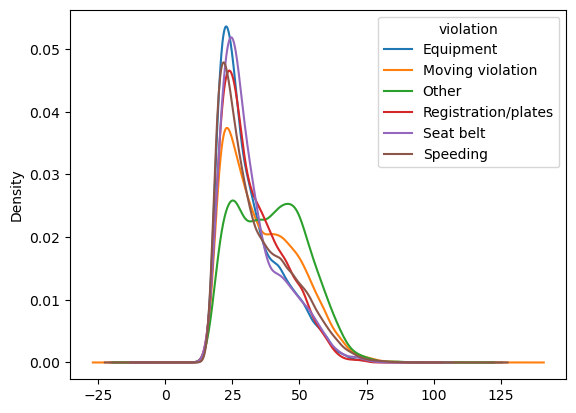

In [51]:
age.plot.density()